In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('./ecoli.csv', sep=',')

In [2]:
print(df.head())

    mcg   gvh   lip  chg   aac  alm1  alm2
0  0.49  0.29  0.48  0.5  0.56  0.24  0.35
1  0.07  0.40  0.48  0.5  0.54  0.35  0.44
2  0.56  0.40  0.48  0.5  0.49  0.37  0.46
3  0.59  0.49  0.48  0.5  0.52  0.45  0.36
4  0.23  0.32  0.48  0.5  0.55  0.25  0.35


In [3]:
from sklearn.preprocessing import MinMaxScaler


In [4]:
scaler = MinMaxScaler()


In [5]:
print(scaler.fit(df))

MinMaxScaler()


In [6]:
print(scaler.data_max_)

[0.89 1.   1.   1.   0.88 1.   0.99]


In [7]:
print(scaler.transform(df))
x = scaler.fit_transform(df)

[[0.5505618  0.1547619  0.         ... 0.63636364 0.21649485 0.35353535]
 [0.07865169 0.28571429 0.         ... 0.61363636 0.32989691 0.44444444]
 [0.62921348 0.28571429 0.         ... 0.55681818 0.35051546 0.46464646]
 ...
 [0.68539326 0.52380952 0.         ... 0.5        0.37113402 0.38383838]
 [0.66292135 0.53571429 0.         ... 0.47727273 0.40206186 0.37373737]
 [0.83146067 0.69047619 0.         ... 0.35227273 0.51546392 0.52525253]]


In [8]:
from sklearn.cluster import KMeans 

In [9]:
print("Max values used for scaling:", scaler.data_max_)

Max values used for scaling: [0.89 1.   1.   1.   0.88 1.   0.99]


In [10]:
# Import the KMeans clustering algorithm from the sklearn library
from sklearn.cluster import KMeans 

# Initialize an empty list to store the Within-Cluster Sum of Squares (WCSS) for each number of clusters
wcss = [] 

# Loop through different values of 'i' (the number of clusters) from 1 to 10
for i in range(1, 11): 
    kmeans = KMeans(n_clusters=i, init='k-means++',n_init = 10, random_state=42)
    kmeans.fit(x)  # Use normalized data
    wcss.append(kmeans.inertia_)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py", line 217, in _count_physical_cores
    raise ValueError(


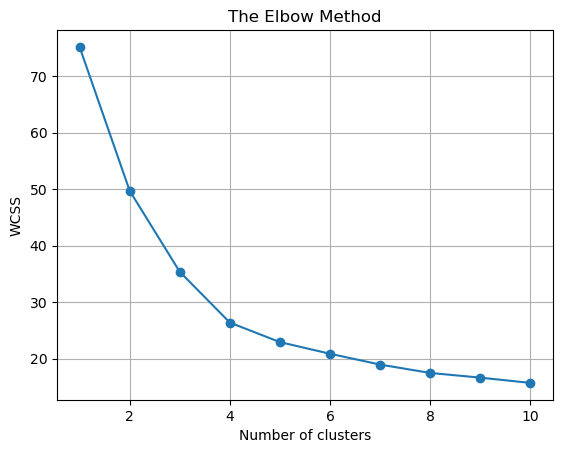

In [11]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [12]:
kmeans1 = KMeans(n_clusters=2, random_state=0, n_init=10).fit(x)
kmeans1.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,

In [13]:
print(kmeans1.labels_)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 0 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]


In [14]:
kmeans1.fit(x)

KMeans(n_clusters=2, n_init=10, random_state=0)

In [15]:
new_data = [[0, 0, 0, 0, 0, 0, 0], [5, 3, 0, 0, 0, 0, 0]]  # 7 features per sample

# Now predict using the new data
predictions = kmeans1.predict(new_data)
print("Predicted clusters:", predictions)

Predicted clusters: [0 1]


In [16]:
kmeans1.cluster_centers_

array([[5.16167018e-01, 4.11987939e-01, 2.62008734e-02, 4.36681223e-03,
        5.35778087e-01, 3.59069014e-01, 3.76604473e-01],
       [6.59666072e-01, 3.89296840e-01, 3.73831776e-02, 4.77048956e-18,
        6.37638063e-01, 7.53637152e-01, 7.79099405e-01]])

In [17]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [18]:
X, y = make_blobs(random_state=42)

In [19]:

kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)


In [20]:
silhouette_score(X, kmeans2.fit_predict(X))

0.7020937832636733